# code for assignment3

## 1) Setup and paths
Load packages, define paths, and set plotting defaults.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve directories relative to this notebook.
ROOT = Path.cwd()
if ROOT.name == "Assignment3":
    ASSIGNMENT_DIR = ROOT
else:
    ASSIGNMENT_DIR = ROOT / "Assignment3"

TABLE_DIR = ASSIGNMENT_DIR / "tables"
FIGURE_DIR = ASSIGNMENT_DIR / "figures"
DATA_PATH = ASSIGNMENT_DIR / "Assignment_3.xlsx"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.frameon": False,
})

print(f"Data path: {DATA_PATH}")
print(f"Table dir: {TABLE_DIR}")
print(f"Figure dir: {FIGURE_DIR}")

Data path: /Users/user/Projects/Econometrics-II/Assignment3/Assignment_3.xlsx
Table dir: /Users/user/Projects/Econometrics-II/Assignment3/tables
Figure dir: /Users/user/Projects/Econometrics-II/Assignment3/figures


## 2) Load and prepare data
Read the assignment data and keep the analysis window January 2012 to December 2023.

In [2]:
def _find_date_column(columns):
    for c in columns:
        c_low = str(c).strip().lower()
        if c_low in {"date", "month", "time", "period"}:
            return c
    return None

raw = pd.read_excel(DATA_PATH)
raw.columns = [str(c).strip() for c in raw.columns]

date_col = _find_date_column(raw.columns)
if date_col is not None:
    raw[date_col] = pd.to_datetime(raw[date_col])
    raw = raw.set_index(date_col)
else:
    # If no explicit date column exists, use a monthly date index from 2000-01.
    raw.index = pd.date_range(start="2000-01-01", periods=len(raw), freq="MS")

expected = ["HousePrice", "Rent", "MortgageRate", "h", "r", "m"]
missing = [c for c in expected if c not in raw.columns]
if missing:
    print("Warning: missing expected columns:", missing)

df = raw.copy().sort_index()
df = df.loc["2012-01-01":"2023-12-01"].copy()

print("Data shape (analysis sample):", df.shape)
print("Date range:", df.index.min().date(), "to", df.index.max().date())
print("Columns:", list(df.columns))

df.head()

Data shape (analysis sample): (144, 7)
Date range: 2012-01-01 to 2023-12-01
Columns: ['Unnamed: 0', 'HousePrice', 'Rent', 'MortgageRate', 'h', 'r', 'm']


,Unnamed: 0,HousePrice,Rent,MortgageRate,h,r,m
Date,,,,,,,
2012-01-01,2012(1),136.595,257.267,3.92,4.917020,5.550114,3.92
2012-02-01,2012(2),136.521,257.842,3.89,4.916478,5.552347,3.89
2012-03-01,2012(3),137.893,258.335,3.95,4.926478,5.554257,3.95
2012-04-01,2012(4),139.143,258.977,3.91,4.935502,5.556739,3.91
2012-05-01,2012(5),140.144,259.481,3.80,4.942670,5.558683,3.80


## 3) Descriptive statistics and export
Create a compact summary table for the report.

In [3]:
summary_vars = [c for c in ["h", "r", "m", "HousePrice", "Rent", "MortgageRate"] if c in df.columns]
summary = df[summary_vars].describe().T[["mean", "std", "min", "max"]].copy()
summary = summary.rename(columns={
    "mean": "Mean",
    "std": "Std. Dev.",
    "min": "Min",
    "max": "Max",
})

table1_path = TABLE_DIR / "table1_summary_stats.tex"
latex_table = summary.to_latex(
    float_format="%.4f",
    caption="Summary statistics, January 2012 to December 2023.",
    label="tab:summary_stats",
)
with open(table1_path, "w", encoding="utf-8") as f:
    f.write(latex_table)

print(f"Saved: {table1_path}")
summary

Saved: /Users/user/Projects/Econometrics-II/Assignment3/tables/table1_summary_stats.tex


,Mean,Std. Dev.,Min,Max
h,5.310791,0.240209,4.916478,5.752677
r,5.751149,0.128742,5.550114,6.016538
m,4.164167,1.069064,2.680000,7.620000
HousePrice,208.551583,52.255377,136.521000,315.033000
Rent,317.174035,41.433251,257.267000,410.156000
MortgageRate,4.164167,1.069064,2.680000,7.620000


## 4) Main data figure and export
Plot the three core variables used in the assignment equation.

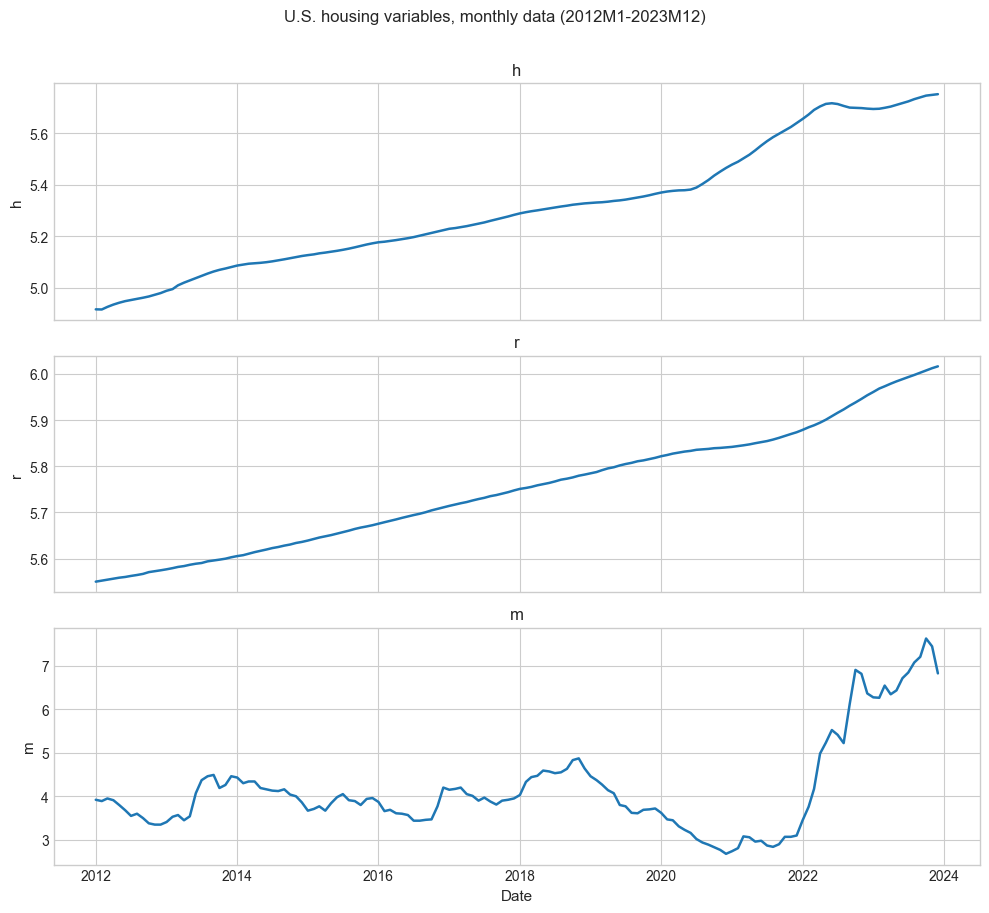

Saved: /Users/user/Projects/Econometrics-II/Assignment3/figures/fig1_series_panel.pdf


In [4]:
plot_cols = [c for c in ["h", "r", "m"] if c in df.columns]
if len(plot_cols) < 3:
    raise ValueError("Expected columns h, r, m were not all found in the analysis sample.")

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
for i, c in enumerate(plot_cols):
    axes[i].plot(df.index, df[c], lw=1.8)
    axes[i].set_title(c)
    axes[i].set_ylabel(c)

axes[-1].set_xlabel("Date")
fig.suptitle("U.S. housing variables, monthly data (2012M1-2023M12)", y=1.01)
fig.tight_layout()

fig1_path = FIGURE_DIR / "fig1_series_panel.pdf"
fig.savefig(fig1_path, bbox_inches="tight")
plt.show()

print(f"Saved: {fig1_path}")

## 5) Unit-root testing (ADF)
Test whether the core variables appear I(1) in levels and I(0) in first differences.

In [5]:
from statsmodels.tsa.stattools import adfuller

core = df[["h", "r", "m"]].copy()

rows = []
for name in core.columns:
    lvl = adfuller(core[name], autolag="AIC", regression="c")
    d1 = adfuller(core[name].diff().dropna(), autolag="AIC", regression="c")

    rows.append({
        "Variable": name,
        "ADF level stat": lvl[0],
        "ADF level p": lvl[1],
        "ADF level lags": lvl[2],
        "ADF diff stat": d1[0],
        "ADF diff p": d1[1],
        "ADF diff lags": d1[2],
    })

unit_root_table = pd.DataFrame(rows).set_index("Variable")

table2_path = TABLE_DIR / "table2_unit_root_tests.tex"
latex_table2 = unit_root_table.to_latex(
    float_format="%.4f",
    caption="ADF unit-root tests for levels and first differences (constant included).",
    label="tab:unit_root_tests",
)
with open(table2_path, "w", encoding="utf-8") as f:
    f.write(latex_table2)

print(f"Saved: {table2_path}")
unit_root_table

Saved: /Users/user/Projects/Econometrics-II/Assignment3/tables/table2_unit_root_tests.tex


,ADF level stat,ADF level p,ADF level lags,ADF diff stat,ADF diff p,ADF diff lags
Variable,,,,,,
h,0.267912,0.975823,14,-3.215974,0.019078,1
r,1.725148,0.998188,12,-2.629625,0.087028,8
m,-1.625531,0.469831,5,-3.655491,0.004785,4


## 6) VAR lag selection on levels
Use information criteria as the first guide for the dynamic specification.

In [6]:
from statsmodels.tsa.api import VAR

var_model = VAR(core)
lag_order = var_model.select_order(maxlags=12)
lag_table = lag_order.summary()

criteria_table = pd.DataFrame({
    "AIC": lag_order.ics["aic"],
    "BIC": lag_order.ics["bic"],
    "HQIC": lag_order.ics["hqic"],
    "FPE": lag_order.ics["fpe"],
})
criteria_table.index.name = "Lag"

k_ar = int(lag_order.selected_orders.get("aic", 2))
k_ar = max(k_ar, 2)
k_ar_diff = k_ar - 1

table3a_path = TABLE_DIR / "table3_lag_selection.tex"
latex_table3a = criteria_table.to_latex(
    float_format="%.5f",
    caption="Lag-order selection criteria for VAR in levels.",
    label="tab:lag_selection",
)
with open(table3a_path, "w", encoding="utf-8") as f:
    f.write(latex_table3a)

print(f"Selected k_ar (levels VAR): {k_ar}")
print(f"Implied k_ar_diff for VECM: {k_ar_diff}")
print(f"Saved: {table3a_path}")
criteria_table.head(12)

Selected k_ar (levels VAR): 4
Implied k_ar_diff for VECM: 3
Saved: /Users/user/Projects/Econometrics-II/Assignment3/tables/table3_lag_selection.tex


/Users/user/Projects/Econometrics-II/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,AIC,BIC,HQIC,FPE
Lag,,,,
0,-10.339068,-10.273550,-10.312445,3.234447e-05
1,-29.014597,-28.752524,-28.908103,2.506945e-13
2,-30.703502,-30.244874,-30.517137,4.631997e-14
3,-30.907671,-30.252488,-30.641435,3.778750e-14
4,-31.149764,-30.298027,-30.803657,2.969369e-14
5,-31.113787,-30.065496,-30.687810,3.083291e-14
6,-31.075776,-29.830930,-30.569928,3.210590e-14
7,-31.053623,-29.612222,-30.467904,3.293612e-14
8,-31.004179,-29.366223,-30.338589,3.476061e-14


## 7) Johansen rank testing and CVAR estimation
Determine the co-integration rank and estimate the preferred VECM.

In [7]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM

# det_order=0 includes an unrestricted constant in the Johansen setup.
joh = coint_johansen(core, det_order=0, k_ar_diff=k_ar_diff)

joh_table = pd.DataFrame({
    "Trace stat": joh.lr1,
    "Trace cv 90%": joh.cvt[:, 0],
    "Trace cv 95%": joh.cvt[:, 1],
    "Trace cv 99%": joh.cvt[:, 2],
}, index=["r = 0", "r <= 1", "r <= 2"])

# Choose smallest non-rejected rank at 5%.
rank = 0
for i in range(len(joh.lr1)):
    if joh.lr1[i] > joh.cvt[i, 1]:
        rank = i + 1

rank = min(max(rank, 1), core.shape[1] - 1)

table3_path = TABLE_DIR / "table4_johansen_trace.tex"
latex_table3 = joh_table.to_latex(
    float_format="%.4f",
    caption="Johansen trace test for co-integration rank (5% decision based on trace cv 95%).",
    label="tab:johansen_trace",
)
with open(table3_path, "w", encoding="utf-8") as f:
    f.write(latex_table3)

print(f"Selected co-integration rank: {rank}")
print(f"Saved: {table3_path}")
joh_table

Selected co-integration rank: 1
Saved: /Users/user/Projects/Econometrics-II/Assignment3/tables/table4_johansen_trace.tex


,Trace stat,Trace cv 90%,Trace cv 95%,Trace cv 99%
r = 0,48.226551,27.0669,29.7961,35.4628
r <= 1,11.564844,13.4294,15.4943,19.9349
r <= 2,3.620660,2.7055,3.8415,6.6349


In [8]:
vecm = VECM(core, k_ar_diff=k_ar_diff, coint_rank=rank, deterministic="co")
vecm_res = vecm.fit()

beta = vecm_res.beta[:, 0]
alpha = vecm_res.alpha[:, 0]

beta_norm = beta / beta[0]
implied = pd.Series({
    "beta_r (h on r)": -beta_norm[1],
    "beta_m (h on m)": -beta_norm[2],
}, name="Estimate")

alpha_series = pd.Series(alpha, index=["alpha_h", "alpha_r", "alpha_m"], name="Estimate")

est_table = pd.concat([implied, alpha_series]).to_frame()

table4_path = TABLE_DIR / "table5_cvar_estimates.tex"
latex_table4 = est_table.to_latex(
    float_format="%.4f",
    caption="Preferred CVAR estimates: implied co-integrating coefficients and adjustment loadings.",
    label="tab:cvar_estimates",
)
with open(table4_path, "w", encoding="utf-8") as f:
    f.write(latex_table4)

print(f"Saved: {table4_path}")
est_table

Saved: /Users/user/Projects/Econometrics-II/Assignment3/tables/table5_cvar_estimates.tex


/Users/user/Projects/Econometrics-II/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,Estimate
beta_r (h on r),1.491760
beta_m (h on m),0.008498
alpha_h,0.015627
alpha_r,0.009081
alpha_m,0.395768


## 8) Diagnostics and additional figures
Create diagnostics table and key figures for equilibrium fit and residual dynamics.

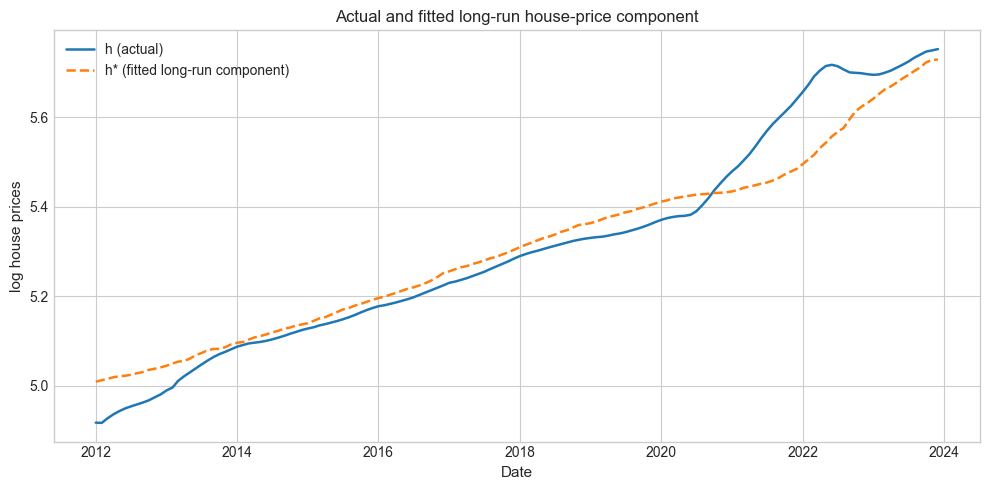

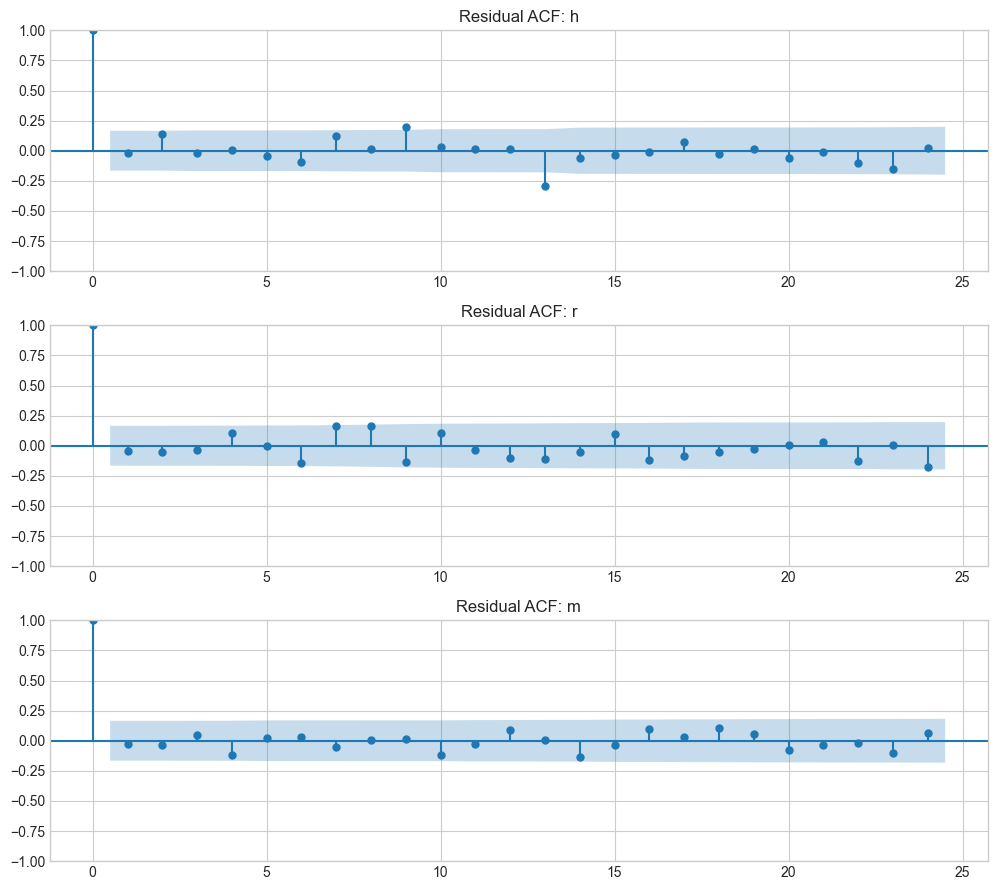

Saved: /Users/user/Projects/Econometrics-II/Assignment3/tables/table6_diagnostics.tex
Saved: /Users/user/Projects/Econometrics-II/Assignment3/figures/fig2_cointegration_fit.pdf
Saved: /Users/user/Projects/Econometrics-II/Assignment3/figures/fig3_residuals_acf.pdf


,Statistic,p-value
Test,,
Whiteness (Portmanteau),83.992264,3.011563e-01
Normality (Jarque-Bera),391.740128,1.667449e-81
ARCH LM (h),19.103691,8.605663e-02
ARCH LM (r),6.463579,8.909363e-01
ARCH LM (m),23.705328,2.230096e-02


In [9]:
from statsmodels.stats.diagnostic import het_arch
from statsmodels.graphics.tsaplots import plot_acf

# Whiteness and normality tests (system-level).
white = vecm_res.test_whiteness(nlags=12)
norm = vecm_res.test_normality()

diag_rows = [
    {"Test": "Whiteness (Portmanteau)", "Statistic": float(white.test_statistic), "p-value": float(white.pvalue)},
    {"Test": "Normality (Jarque-Bera)", "Statistic": float(norm.test_statistic), "p-value": float(norm.pvalue)},
]

# ARCH LM by equation.
resid = pd.DataFrame(vecm_res.resid, columns=["h", "r", "m"], index=core.index[-len(vecm_res.resid):])
for c in resid.columns:
    arch_stat, arch_p, _, _ = het_arch(resid[c], nlags=12)
    diag_rows.append({"Test": f"ARCH LM ({c})", "Statistic": float(arch_stat), "p-value": float(arch_p)})

diag_table = pd.DataFrame(diag_rows).set_index("Test")

table5_path = TABLE_DIR / "table6_diagnostics.tex"
latex_table5 = diag_table.to_latex(
    float_format="%.4f",
    caption="Misspecification diagnostics for preferred CVAR specification.",
    label="tab:diagnostics",
)
with open(table5_path, "w", encoding="utf-8") as f:
    f.write(latex_table5)

# Figure 2: actual h and fitted long-run component.
beta_r = -beta_norm[1]
beta_m = -beta_norm[2]
h_star_raw = beta_r * core["r"] + beta_m * core["m"]
offset = (core["h"] - h_star_raw).mean()
h_star = h_star_raw + offset

fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.plot(core.index, core["h"], label="h (actual)", lw=1.8)
ax2.plot(core.index, h_star, label="h* (fitted long-run component)", lw=1.8, linestyle="--")
ax2.set_title("Actual and fitted long-run house-price component")
ax2.set_xlabel("Date")
ax2.set_ylabel("log house prices")
ax2.legend()
fig2.tight_layout()
fig2_path = FIGURE_DIR / "fig2_cointegration_fit.pdf"
fig2.savefig(fig2_path, bbox_inches="tight")
plt.show()

# Figure 3: residual ACF by equation.
fig3, axes3 = plt.subplots(3, 1, figsize=(10, 9), sharex=False)
for i, c in enumerate(["h", "r", "m"]):
    plot_acf(resid[c], lags=24, ax=axes3[i])
    axes3[i].set_title(f"Residual ACF: {c}")
fig3.tight_layout()
fig3_path = FIGURE_DIR / "fig3_residuals_acf.pdf"
fig3.savefig(fig3_path, bbox_inches="tight")
plt.show()

print(f"Saved: {table5_path}")
print(f"Saved: {fig2_path}")
print(f"Saved: {fig3_path}")
diag_table